# WanderLost — Customer Persona Segmentation

Unsupervised segmentation of **4,000 advertising campaigns** into behavioural groups using K-Means, with a data-grounded read on what separates high-revenue campaigns from the rest.

> Data is simulated for demonstration. No real company or customer data is used. This is a methods and communication showcase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
pio.renderers.default = "plotly_mimetype" 

## 1. Load the data

In [2]:
df = pd.read_csv("WanderLost_Cleaned.csv")  # in Colab, upload the CSV and adjust the path
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Date,Campaign_ID,Campaign_Name,Ad_Set_Name,Platform,Objective,Target_Audience,Location,Age_Group,Gender,...,Leads,Add_to_Cart,Purchases,Conversion_Rate_Percent,Revenue_INR,ROAS,Bounce_Rate_Percent,Avg_Session_Duration_Sec,Landing_Page,UTM_Campaign
0,2025-06-25,CMP-2561,Luxury Digital Detox,Pre-emptive 5thgeneration circuit,Facebook,Lead Generation,High Income Professionals,Mangalore,25-34,Male,...,0,0,0,0.00,0,0.00,54.19,209,/book-now,luxury_digital_detox
1,2025-04-02,CMP-8333,Luxury Nature Escape,Networked tangible matrix,Facebook,Lead Generation,Business Owners,Indore,45-54,Male,...,17,6,3,1.99,360000,23.28,66.52,54,/mental-reset-retreat,luxury_nature_escape
2,2025-08-13,CMP-1948,Eco Adventure Cabins,Innovative value-added projection,Instagram,Traffic,Gen-Z Eco Travelers,Pune,18-24,Other,...,1,0,0,0.00,0,0.00,37.00,699,/mental-reset-retreat,eco_adventure_cabins
3,2025-02-09,CMP-6530,Luxury Digital Detox,Configurable interactive policy,Facebook,Traffic,High Income Professionals,Mangalore,18-24,Male,...,133,54,8,0.62,760000,6.09,46.00,800,/weekend-reset,luxury_digital_detox
4,2025-03-24,CMP-5445,Eco Adventure Cabins,De-engineered discrete initiative,Instagram,Engagement,Gen-Z Eco Travelers,Bengaluru,45-54,Female,...,1,0,0,0.00,0,0.00,66.55,876,/book-now,eco_adventure_cabins


## 2. Validate data integrity

In [3]:
print("Null values   :", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Null values   : 0
Duplicate rows: 0


## 3. Select behavioural features

Clustering is based on financial, engagement, and conversion behaviour rather than demographics.

*Note: `Revenue` and `Purchases` are highly correlated (~0.96) and `ROAS` correlates ~0 with the others; a cleaner pass would drop a redundant feature — see the README limitations.*

In [4]:
features = [
    "Spend_INR", "Revenue_INR", "ROAS", "CTR_Percent",
    "Conversion_Rate_Percent", "Avg_Session_Duration_Sec",
    "Bounce_Rate_Percent", "Purchases",
]
X = df[features]
X.head()

,Spend_INR,Revenue_INR,ROAS,CTR_Percent,Conversion_Rate_Percent,Avg_Session_Duration_Sec,Bounce_Rate_Percent,Purchases
0,193.14,0,0.00,0.03,0.00,209,54.19,0
1,15460.89,360000,23.28,0.69,1.99,54,66.52,3
2,4194.68,0,0.00,2.85,0.00,699,37.00,0
3,124694.77,760000,6.09,1.50,0.62,800,46.00,8
4,24387.30,0,0.00,3.87,0.00,876,66.55,0


## 4. Standardise the features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5. Choosing the number of clusters (k)

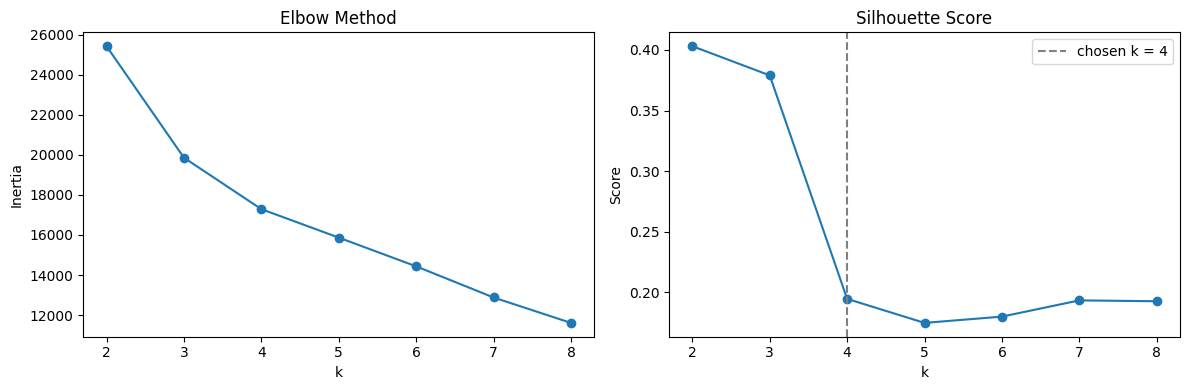

In [6]:
inertia, sil, K = [], [], range(2, 9)
for k in K:
    m = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X_scaled)
    inertia.append(m.inertia_)
    sil.append(silhouette_score(X_scaled, m.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K, inertia, "o-"); ax[0].set(title="Elbow Method", xlabel="k", ylabel="Inertia")
ax[1].plot(K, sil, "o-"); ax[1].axvline(4, ls="--", c="grey", label="chosen k = 4")
ax[1].set(title="Silhouette Score", xlabel="k", ylabel="Score"); ax[1].legend()
plt.tight_layout(); plt.show()

**On the choice of k = 4:** the elbow flattens around k = 3–4, while silhouette favours fewer clusters (≈0.40 at k = 2 vs ≈0.20 at k = 4). Four clusters were chosen for interpretability; one of them turns out to be a small outlier pocket.

## 6. Fit K-Means (k = 4)

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df["Persona_Cluster"] = kmeans.fit_predict(X_scaled)

## 7. Map clusters to segments

Cluster numbers are mapped to interpretable names based on each cluster's profile.
*(If you re-run on a different scikit-learn version and the labels permute, verify against the cluster profile below.)*

In [8]:
segment_names = {
    0: "Deep Explorers",
    1: "Casual Wellness Browsers",
    2: "Luxury High-Intent Buyers",
    3: "Frequent Wellness Buyers",
}
df["Persona_Name"] = df["Persona_Cluster"].map(segment_names)
df["Persona_Name"].value_counts()

Persona_Name
Deep Explorers               1770
Casual Wellness Browsers     1684
Frequent Wellness Buyers      535
Luxury High-Intent Buyers      11
Name: count, dtype: int64

## 8. Segment economics

In [9]:
summary = (
    df.groupby("Persona_Name")
      .agg(Campaigns=("Campaign_ID", "count"),
           Revenue_INR=("Revenue_INR", "sum"),
           Spend_INR=("Spend_INR", "sum"),
           Converted_pct=("Purchases", lambda s: 100 * (s > 0).mean()),
           Avg_Session_Sec=("Avg_Session_Duration_Sec", "mean"))
)
summary["Revenue_Share_%"] = (100 * summary["Revenue_INR"] / summary["Revenue_INR"].sum())
summary["ROAS"] = summary["Revenue_INR"] / summary["Spend_INR"]
summary.sort_values("Revenue_INR", ascending=False).round(2)

,Campaigns,Revenue_INR,Spend_INR,Converted_pct,Avg_Session_Sec,Revenue_Share_%,ROAS
Persona_Name,,,,,,,
Frequent Wellness Buyers,535,2104389000,1.055946e+08,100.00,489.95,49.95,19.93
Deep Explorers,1770,1116050000,8.465175e+07,79.38,737.82,26.49,13.18
Casual Wellness Browsers,1684,964110000,7.606551e+07,77.49,256.10,22.88,12.67
Luxury High-Intent Buyers,11,28559000,8.835770e+03,100.00,331.82,0.68,3232.20


## Interpreting the segments — important caveats

The clustering uses **behavioural and financial features only**. Three honest notes before reading any persona narrative:

- **The segments primarily separate on conversion, revenue magnitude, and session length** (see the cluster profile below). Frequent Wellness Buyers and the outlier group convert at 100%; the two larger segments (~78% conversion) differ mainly by session duration.
- **Names and motivations are interpretive.** The Platform and Age columns are roughly uniform across segments, so segment-level channel or demographic claims are hypotheses to test — not findings.
- **Some metrics are circular.** Segments are defined by revenue / ROAS / purchases, so differences in those are expected by construction.

## 9. Cluster profile heatmap

Standardised mean of each feature per segment — the clearest single view of what defines each group. (Positive = above the dataset average; negative = below.)

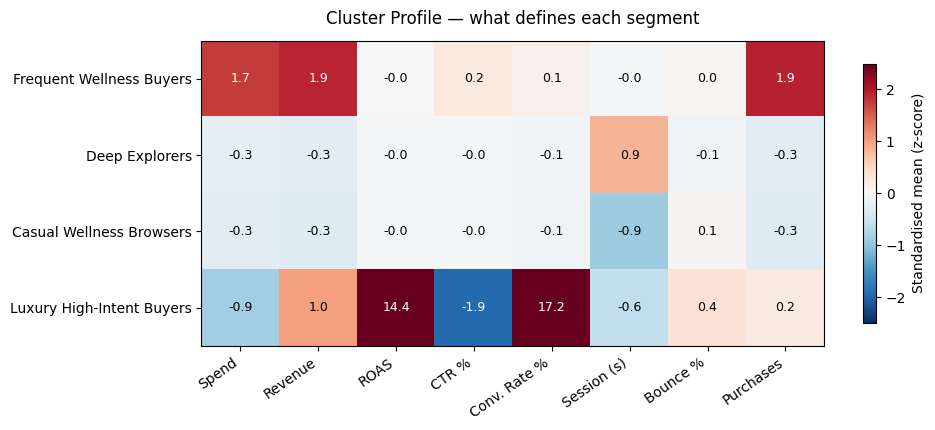

In [10]:
feat_labels = ["Spend", "Revenue", "ROAS", "CTR %", "Conv. Rate %",
               "Session (s)", "Bounce %", "Purchases"]
order = ["Frequent Wellness Buyers", "Deep Explorers",
         "Casual Wellness Browsers", "Luxury High-Intent Buyers"]

Xs_df = pd.DataFrame(X_scaled, columns=features)
Xs_df["Persona_Name"] = df["Persona_Name"].values
prof = Xs_df.groupby("Persona_Name")[features].mean().reindex(order)

fig, ax = plt.subplots(figsize=(10, 4.4))
im = ax.imshow(prof.values, cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_xticks(range(len(feat_labels))); ax.set_xticklabels(feat_labels, rotation=35, ha="right")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
for i in range(prof.shape[0]):
    for j in range(prof.shape[1]):
        v = prof.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                color="white" if abs(v) > 1.4 else "black", fontsize=9)
cb = fig.colorbar(im, ax=ax, shrink=0.85); cb.set_label("Standardised mean (z-score)")
ax.set_title("Cluster Profile — what defines each segment", pad=12)
plt.tight_layout(); plt.show()

**Reading the heatmap:** Frequent Wellness Buyers are defined by high spend, revenue, and purchases. Deep Explorers vs Casual Wellness Browsers differ on almost nothing *except* session duration (+0.9 vs −0.9). Luxury High-Intent Buyers are a clear outlier — extreme ROAS and conversion rate (z ≈ 14 and 17) on tiny spend — which is why they are treated as noise rather than a stable segment.

## 10. 3D segment map

In [11]:
fig = px.scatter_3d(
    df, x="Spend_INR", y="Revenue_INR", z="Avg_Session_Duration_Sec",
    color="Persona_Name", opacity=0.7, title="3D Segment Mapping",
    labels={"Spend_INR": "Ad Spend (INR)", "Revenue_INR": "Revenue (INR)",
            "Avg_Session_Duration_Sec": "Session Duration (sec)", "Persona_Name": "Segment"},
    hover_data=["ROAS", "Conversion_Rate_Percent", "Purchases"],
)
fig.update_traces(marker=dict(size=4))
fig.show()

## Segments at a glance

| Segment | What the data shows | Interpretation (hypothesis) |
|---|---|---|
| **Frequent Wellness Buyers** (n=535) | ~50% of revenue, 100% conversion, highest spend & purchases; mild LinkedIn skew (41% vs 39% FB) | High-value, high-intent buyers |
| **Deep Explorers** (n=1,770) | ~26% revenue, 79% conversion, longest sessions (~12 min) | Research thoroughly before buying |
| **Casual Wellness Browsers** (n=1,684) | ~23% revenue, 78% conversion, shortest sessions (~4 min) | Quick, impulse-style sessions |
| **Luxury High-Intent Buyers** (n=11) | Extreme ROAS on negligible spend — statistical outliers | Excluded from strategy |

**Note:** Channel and demographic columns are uniform across segments, so the interpretations above are hypotheses to A/B test, not findings. Frequent Wellness Buyers drive ~50% of revenue at 100% conversion — the single most valuable group. Full analysis and caveats in the [README](README.md).